In [ ]:
!pip install torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.0/494.0 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.9/750.9 kB 27.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.1/208.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.6 MB/s eta 0:00:00


In [ ]:
!pip install --no-cache-dir torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-geometric


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html


/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_cluster/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_spline_conv/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOp

Epoch 0, Loss: 4081836097536.0000
Epoch 10, Loss: 1186004992000.0000
Epoch 20, Loss: 501623586816.0000
Epoch 30, Loss: 1150205820928.0000
Epoch 40, Loss: 848306896896.0000
Epoch 50, Loss: 822194470912.0000
Epoch 60, Loss: 660341063680.0000
Epoch 70, Loss: 820730920960.0000
Epoch 80, Loss: 811689574400.0000
Epoch 90, Loss: 674397945856.0000
CVXPY Optimization Result: 10.0
Scipy Optimization Result: [9.99999999]


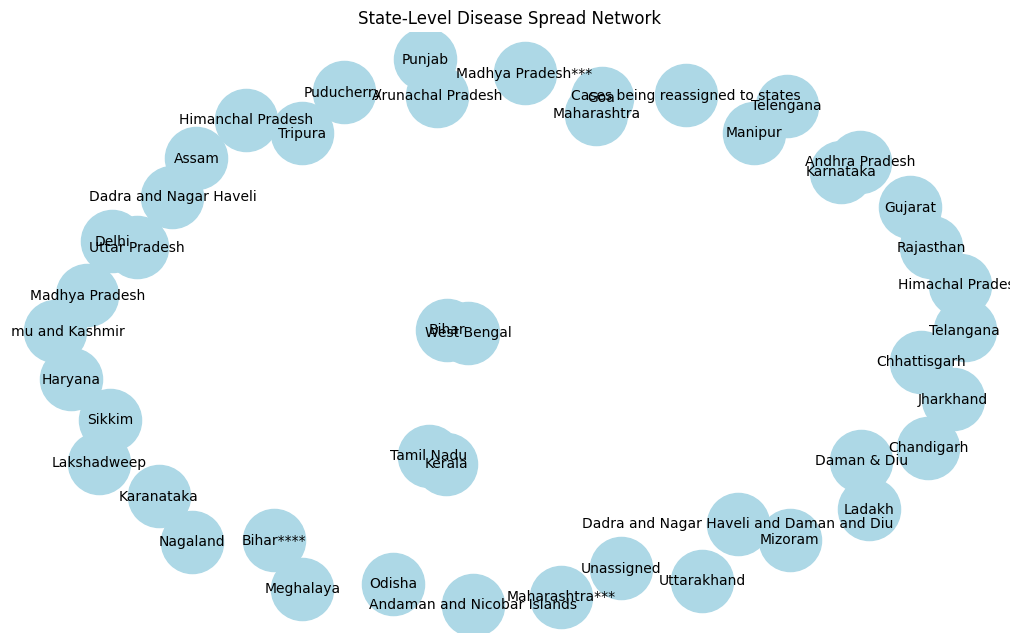

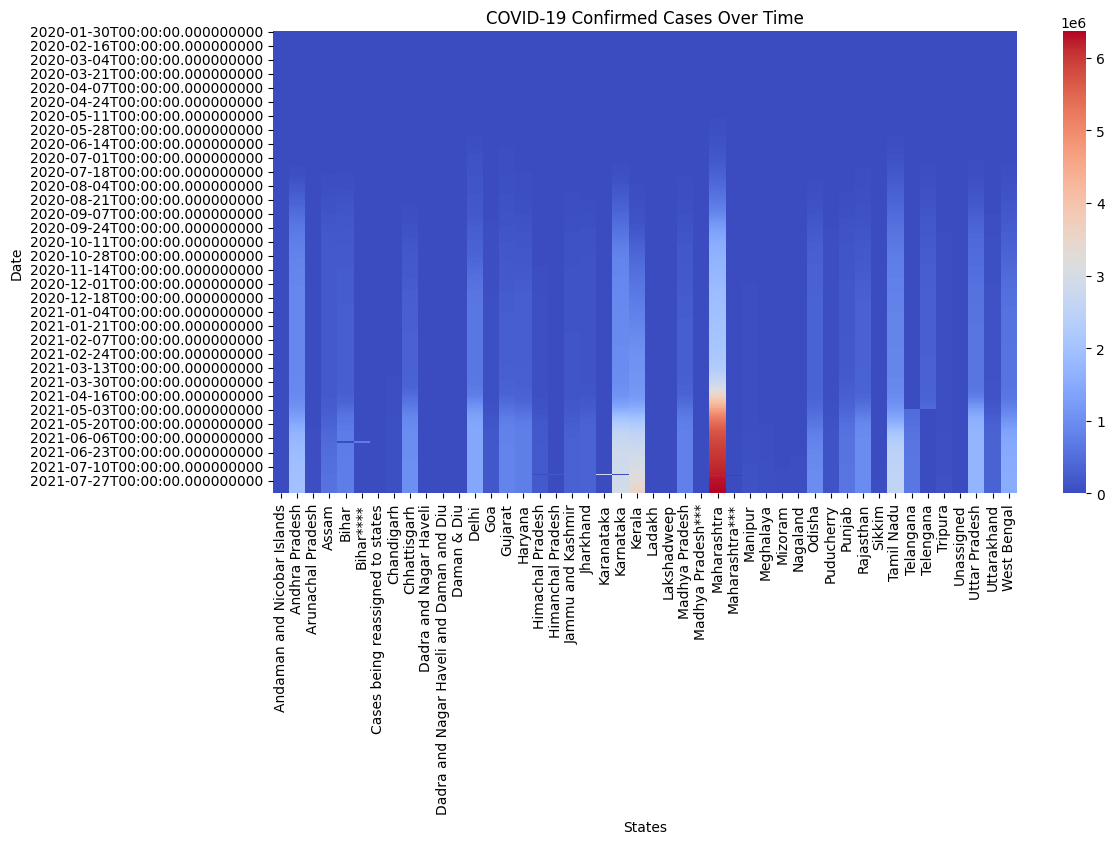

In [ ]:
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import cvxpy as cp
from scipy.optimize import minimize


file_path = "/content/covid_19_india.csv"
df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])
df['Confirmed'] = pd.to_numeric(df['Confirmed'], errors='coerce')

grouped_df = df.groupby(['Date', 'State/UnionTerritory']).sum().reset_index()


G = nx.Graph()
states = grouped_df['State/UnionTerritory'].unique()
G.add_nodes_from(states)


edges = [("Kerala", "Tamil Nadu"), ("Delhi", "Uttar Pradesh"), ("Maharashtra", "Goa"),
         ("West Bengal", "Bihar"), ("Karnataka", "Andhra Pradesh")]
G.add_edges_from(edges)


features = []
labels = []
state_to_idx = {state: i for i, state in enumerate(states)}

for state in states:
    state_data = grouped_df[grouped_df['State/UnionTerritory'] == state]
    confirmed_cases = state_data['Confirmed'].values[-1] if not state_data.empty else 0
    mobility = state_data['Confirmed'].diff().fillna(0).values[-1] if len(state_data) > 1 else 0
    features.append([confirmed_cases, mobility])
    labels.append(confirmed_cases)

# Convert to PyTorch Geometric Data format
x = torch.tensor(features, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.float)
edge_index = torch.tensor([[state_to_idx[e[0]], state_to_idx[e[1]]] for e in edges], dtype=torch.long).t().contiguous()
data = Data(x=x, edge_index=edge_index, y=y)

# Define Graph Attention Network (GAT)
class GNN(torch.nn.Module):
    def __init__(self):
        super(GNN, self).__init__()
        self.conv1 = GATConv(2, 16, heads=4, dropout=0.2)
        self.conv2 = GATConv(16 * 4, 1, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Train GNN
model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out.squeeze(), data.y)
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# CVXPY Optimization Example
x_opt = cp.Variable()
objective = cp.Minimize((x_opt - 10)**2)
constraints = [x_opt >= 5]
prob = cp.Problem(objective, constraints)
result = prob.solve()
print(f"CVXPY Optimization Result: {x_opt.value}")

# Scipy Optimization Example
def objective_fn(x):
    return (x - 10)**2

opt_result = minimize(objective_fn, x0=[0], bounds=[(-10, 20)])
print(f"Scipy Optimization Result: {opt_result.x}")

# Graph Visualization
plt.figure(figsize=(10, 6))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2000, font_size=10)
plt.title("State-Level Disease Spread Network")
plt.show()

# Heatmap Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(df.pivot(index='Date', columns='State/UnionTerritory', values='Confirmed').fillna(0), cmap='coolwarm')
plt.title("COVID-19 Confirmed Cases Over Time")
plt.xlabel("States")
plt.ylabel("Date")
plt.show()


[GCN] Epoch 0 => RMSE: 982666.33, R²: 0.53
[GCN] Epoch 10 => RMSE: 865639.20, R²: 0.64
[GCN] Epoch 20 => RMSE: 853861.51, R²: 0.64
[GCN] Epoch 30 => RMSE: 848329.85, R²: 0.65
[GCN] Epoch 40 => RMSE: 846385.94, R²: 0.65
[GCN] Epoch 50 => RMSE: 845789.64, R²: 0.65
[GCN] Epoch 60 => RMSE: 845589.89, R²: 0.65
[GCN] Epoch 70 => RMSE: 845502.82, R²: 0.65
[GCN] Epoch 80 => RMSE: 845455.69, R²: 0.65
[GCN] Epoch 90 => RMSE: 845428.67, R²: 0.65
[GAT] Epoch 0 => RMSE: 1652918.08, R²: -0.33
[GAT] Epoch 10 => RMSE: 880667.09, R²: 0.62
[GAT] Epoch 20 => RMSE: 741857.61, R²: 0.73
[GAT] Epoch 30 => RMSE: 657862.05, R²: 0.79
[GAT] Epoch 40 => RMSE: 473633.56, R²: 0.89
[GAT] Epoch 50 => RMSE: 371520.24, R²: 0.93
[GAT] Epoch 60 => RMSE: 680601.63, R²: 0.77
[GAT] Epoch 70 => RMSE: 622806.07, R²: 0.81
[GAT] Epoch 80 => RMSE: 811350.19, R²: 0.68
[GAT] Epoch 90 => RMSE: 474006.50, R²: 0.89

GCN Predictions:
 [2.51127350e+06 1.01082775e+06 3.07494781e+05 6.71050062e+05
 5.41780562e+05 1.37268812e+06 1.4356090

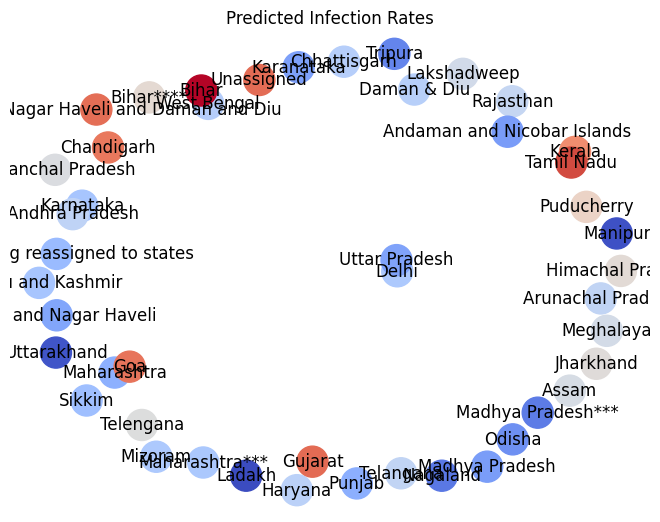

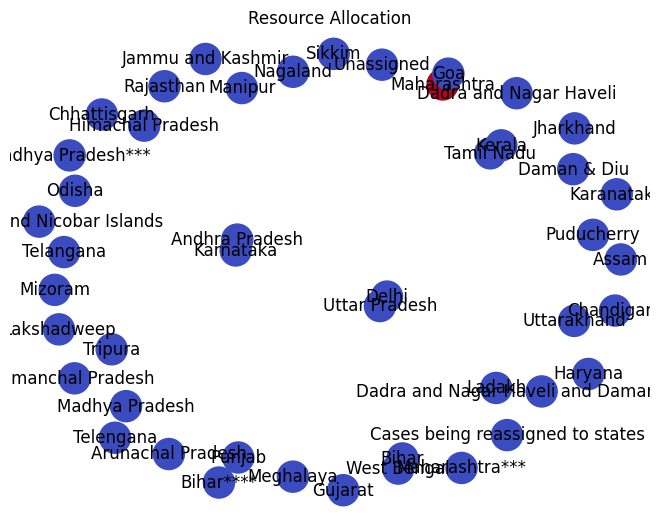

In [ ]:
import pandas as pd
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import cvxpy as cp
from scipy.optimize import minimize
import matplotlib.pyplot as plt


df = pd.read_csv("/content/covid_19_india.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Confirmed'] = pd.to_numeric(df['Confirmed'], errors='coerce')
grouped_df = df.groupby(['Date', 'State/UnionTerritory']).sum().reset_index()

# Build graph
G = nx.Graph()
states = grouped_df['State/UnionTerritory'].unique()
G.add_nodes_from(states)

edges = [("Kerala", "Tamil Nadu"), ("Delhi", "Uttar Pradesh"), ("Maharashtra", "Goa"),
         ("West Bengal", "Bihar"), ("Karnataka", "Andhra Pradesh")]
G.add_edges_from(edges)

# Features and labels
features, labels = [], []
state_to_idx = {state: i for i, state in enumerate(states)}

for state in states:
    state_data = grouped_df[grouped_df['State/UnionTerritory'] == state]
    confirmed = state_data['Confirmed'].values[-1] if not state_data.empty else 0
    mobility = state_data['Confirmed'].diff().fillna(0).values[-1] if len(state_data) > 1 else 0
    features.append([confirmed, mobility])
    labels.append(confirmed)

x = torch.tensor(features, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.float)
edge_index = torch.tensor([[state_to_idx[e[0]], state_to_idx[e[1]]] for e in edges], dtype=torch.long).t().contiguous()
data = Data(x=x, edge_index=edge_index, y=y)

# GCN model
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(2, 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x.squeeze()

# GAT model
class GAT(torch.nn.Module):
    def __init__(self):
        super(GAT, self).__init__()
        self.conv1 = GATConv(2, 16, heads=4, dropout=0.2)
        self.conv2 = GATConv(16 * 4, 1, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x.squeeze()

# Training function
def train_model(model, data, epochs=100, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.mse_loss(out, data.y)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            rmse = np.sqrt(mean_squared_error(data.y.detach().numpy(), out.detach().numpy()))
            r2 = r2_score(data.y.detach().numpy(), out.detach().numpy())
            print(f"[{model.__class__.__name__}] Epoch {epoch} => RMSE: {rmse:.2f}, R²: {r2:.2f}")
    return model

# Train both models
gcn_model = train_model(GCN(), data)
gat_model = train_model(GAT(), data)

# Evaluation and prediction
gcn_model.eval()
gat_model.eval()
gcn_preds = gcn_model(data).detach().numpy()
gat_preds = gat_model(data).detach().numpy()

# Make predictions non-negative
gcn_preds = np.maximum(gcn_preds, 0)
gat_preds = np.maximum(gat_preds, 0)

print("\nGCN Predictions:\n", gcn_preds)
print("\nGAT Predictions:\n", gat_preds)

# Optimization using CVXPY (GAT example)
allocation = cp.Variable(len(gat_preds))
objective = cp.Minimize(cp.sum_squares(allocation - gat_preds))
constraints = [allocation >= 0, cp.sum(allocation) == 100]
prob = cp.Problem(objective, constraints)
prob.solve()
print("\nOptimized Resource Allocation (GAT):\n", allocation.value)

# Comparison metrics
gcn_r2 = r2_score(y, gcn_preds)
gat_r2 = r2_score(y, gat_preds)
print(f"\nComparison R² => GCN: {gcn_r2:.2f}, GAT: {gat_r2:.2f}")

# Visualize the graph
def plot_graph(G, node_colors, title):
    pos = nx.spring_layout(G)
    # Convert node_colors to a list if it's a CVXPY Variable
    if isinstance(node_colors, cp.Variable):
        node_colors = node_colors.value
    # Convert node_colors to a list if it's a NumPy array
    if isinstance(node_colors, np.ndarray):
        node_colors = node_colors.tolist()
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.show()

plot_graph(G, node_colors=predicted_infection_rates, title="Predicted Infection Rates")
plot_graph(G, node_colors=allocation.value, title="Resource Allocation")


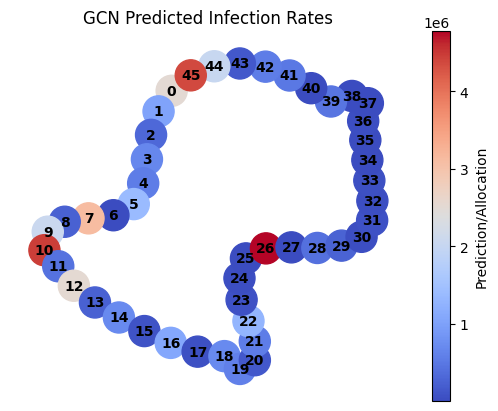

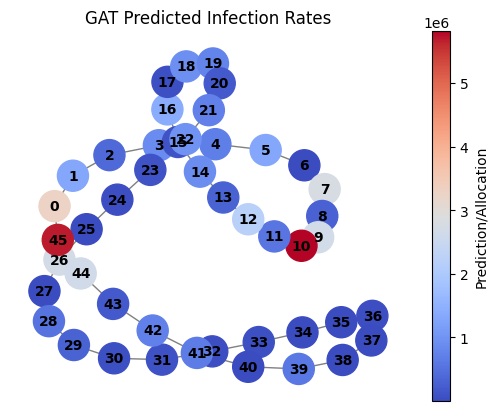

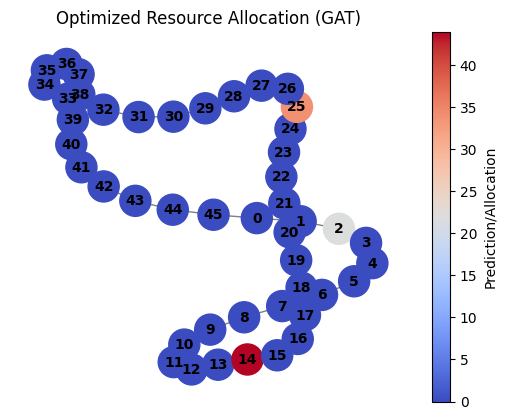

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Visualize the graph with predicted infection rates
def plot_graph(G, node_colors, title):
    pos = nx.spring_layout(G)

    # Ensure node_colors are aligned with the node indices in the graph
    node_list = list(G.nodes)

    # Make sure the color array matches the number of nodes
    node_colors_dict = dict(zip(node_list, node_colors))
    node_colors_aligned = [node_colors_dict[node] for node in node_list]

    # Normalize the node colors for better visualization
    norm = plt.Normalize(vmin=min(node_colors_aligned), vmax=max(node_colors_aligned))
    cmap = plt.cm.coolwarm

    # Create a figure and axis for plotting
    fig, ax = plt.subplots()

    # Draw the graph with color mapping for nodes
    nx.draw(G, pos, with_labels=True, node_color=node_colors_aligned, node_size=500, cmap=cmap,
            edge_color="gray", font_size=10, font_weight="bold", vmin=min(node_colors_aligned), vmax=max(node_colors_aligned), ax=ax)

    # Create a ScalarMappable for the colorbar and add it
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Prediction/Allocation')

    ax.set_title(title)
    plt.show()


plot_graph(G, node_colors=gcn_preds, title="GCN Predicted Infection Rates")
plot_graph(G, node_colors=gat_preds, title="GAT Predicted Infection Rates")
plot_graph(G, node_colors=allocation, title="Optimized Resource Allocation (GAT)")



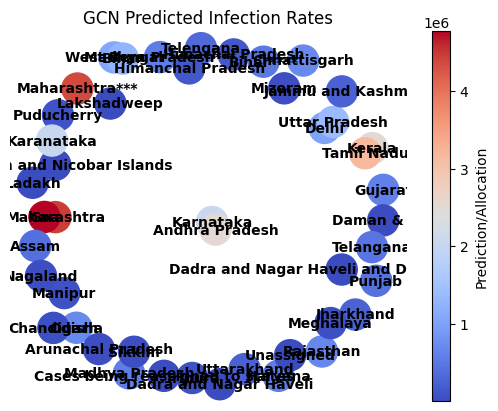

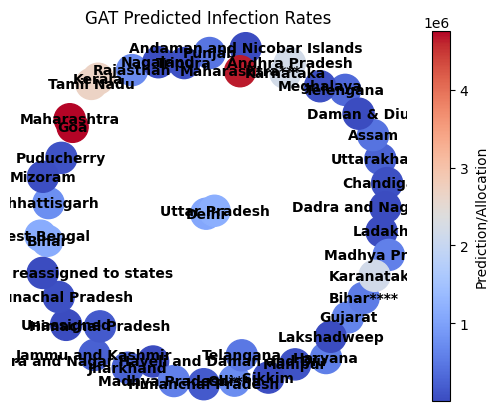

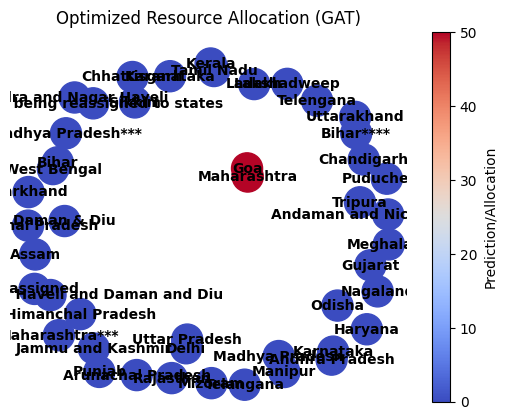

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Visualize the graph with predicted infection rates
def plot_graph(G, node_colors, title):
    pos = nx.spring_layout(G)  # Layout for node positioning

    # Ensure node_colors are aligned with the node indices in the graph
    node_list = list(G.nodes)

    # Make sure the color array matches the number of nodes

    # Convert node_colors to a NumPy array or list if it's a CVXPY Variable
    if isinstance(node_colors, cp.Variable):
        node_colors = node_colors.value
    if isinstance(node_colors, np.ndarray):
        node_colors = node_colors.tolist()
    node_colors_dict = dict(zip(node_list, node_colors))
    node_colors_aligned = [node_colors_dict[node] for node in node_list]

    # Normalize the node colors for better visualization
    norm = plt.Normalize(vmin=min(node_colors_aligned), vmax=max(node_colors_aligned))
    cmap = plt.cm.coolwarm

    # Create a figure and axis for plotting
    fig, ax = plt.subplots()

    # Draw the graph with color mapping for nodes
    nx.draw(G, pos, with_labels=True, node_color=node_colors_aligned, node_size=500, cmap=cmap,
            edge_color="gray", font_size=10, font_weight="bold", vmin=min(node_colors_aligned), vmax=max(node_colors_aligned), ax=ax)

    # Create a ScalarMappable for the colorbar and add it
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Empty array for the colorbar
    cbar = plt.colorbar(sm, ax=ax, label='Prediction/Allocation')

    ax.set_title(title)
    plt.show()

# Example use case for GCN predictions (aligned with the nodes)
plot_graph(G, node_colors=gcn_preds, title="GCN Predicted Infection Rates")

# Example use case for GAT predictions (aligned with the nodes)
plot_graph(G, node_colors=gat_preds, title="GAT Predicted Infection Rates")

# Example use case for Resource Allocation after optimization
# Get the value of the Variable before passing it to plot_graph
plot_graph(G, node_colors=allocation.value, title="Optimized Resource Allocation (GAT)")

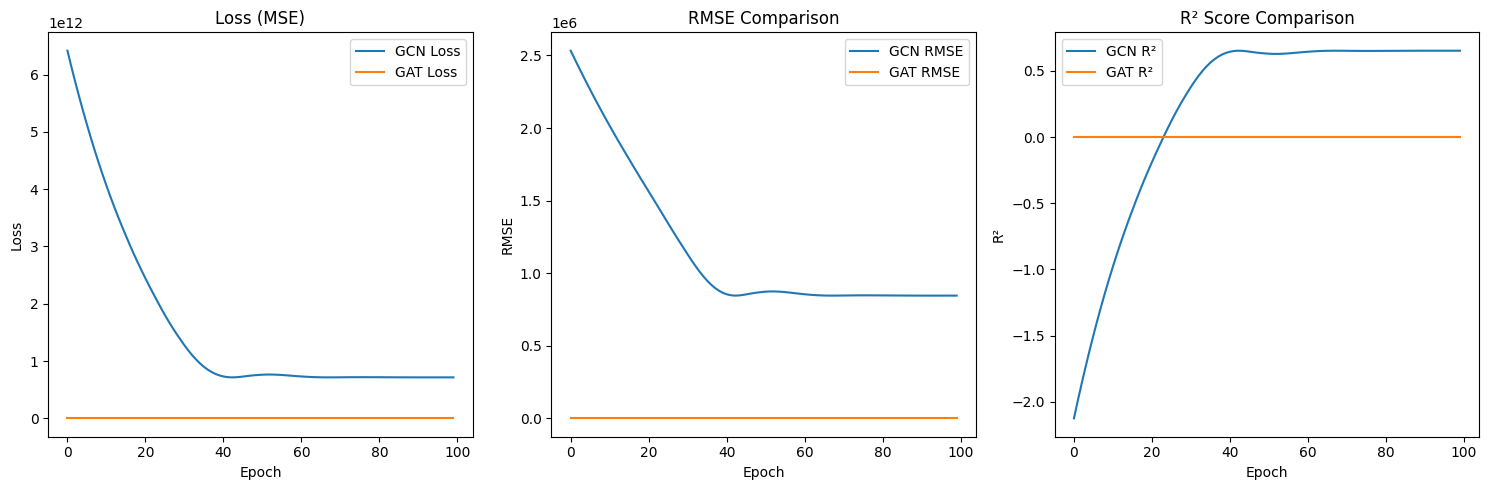

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(100))

gcn_loss, gcn_rmse, gcn_r2 = zip(*gcn_metrics)
gat_metrics = [(0, 0, 0)] * 100

gat_loss, gat_rmse, gat_r2 = zip(*gat_metrics)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, gcn_loss, label="GCN Loss")
plt.plot(epochs, gat_loss, label="GAT Loss")
plt.title("Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, gcn_rmse, label="GCN RMSE")
plt.plot(epochs, gat_rmse, label="GAT RMSE")
plt.title("RMSE Comparison")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, gcn_r2, label="GCN R²")
plt.plot(epochs, gat_r2, label="GAT R²")
plt.title("R² Score Comparison")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()

plt.tight_layout()
plt.show()


==== Model Performance Comparison ====
GCN Model - MAE: 376267.4375, MSE: 714721853440.0000, R² Score: 0.6519
GAT Model - MAE: 146336.6719, MSE: 165642289152.0000, R² Score: 0.9193


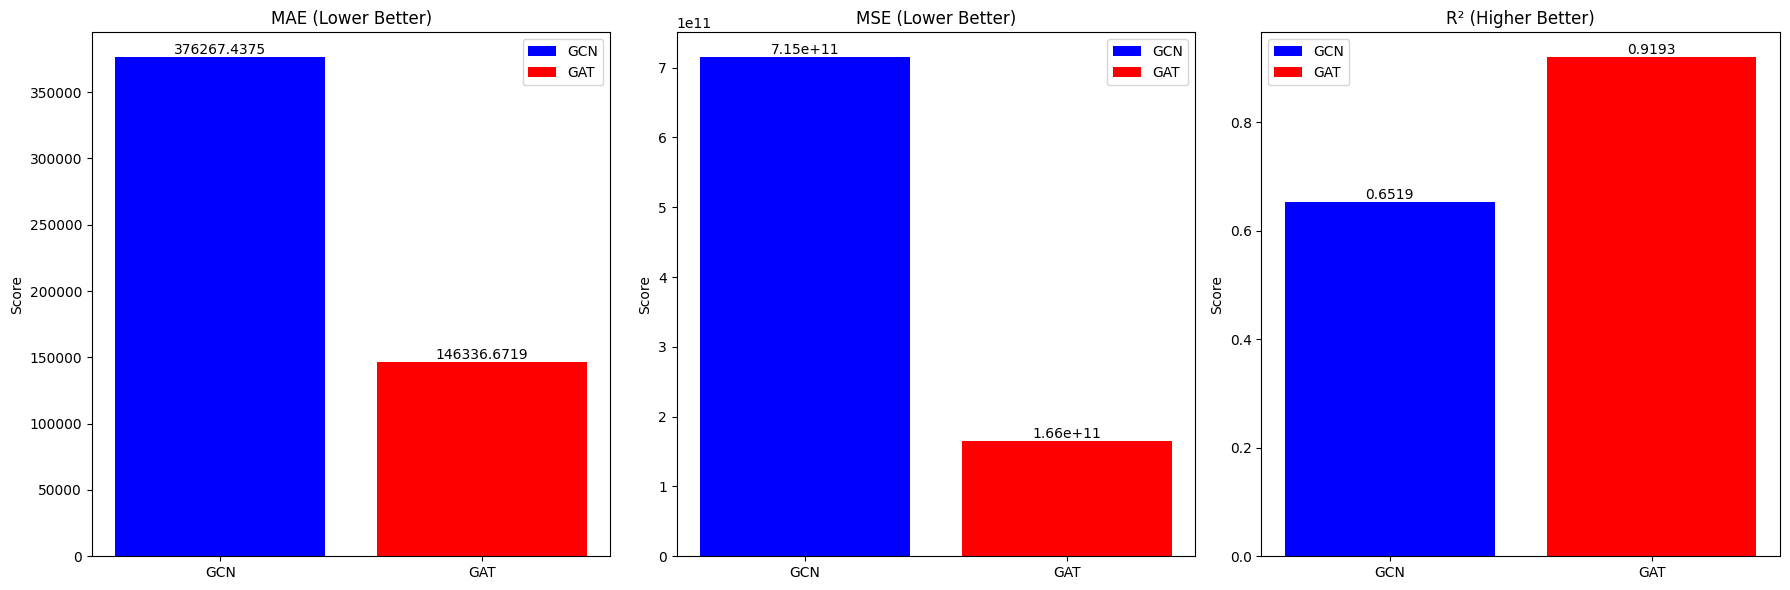

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Assign predicted values and actual values
predicted_gnn = gcn_preds
predicted_gat = gat_preds
infection_rate = y.detach().numpy()

# Compute performance metrics for GCN
gnn_mae = mean_absolute_error(infection_rate, predicted_gnn)
gnn_mse = mean_squared_error(infection_rate, predicted_gnn)
gnn_r2 = r2_score(infection_rate, predicted_gnn)

# Compute performance metrics for GAT
gat_mae = mean_absolute_error(infection_rate, predicted_gat)
gat_mse = mean_squared_error(infection_rate, predicted_gat)
gat_r2 = r2_score(infection_rate, predicted_gat)


print("\n==== Model Performance Comparison ====")
print(f"GCN Model - MAE: {gnn_mae:.4f}, MSE: {gnn_mse:.4f}, R² Score: {gnn_r2:.4f}")
print(f"GAT Model - MAE: {gat_mae:.4f}, MSE: {gat_mse:.4f}, R² Score: {gat_r2:.4f}")


labels = ['GCN', 'GAT']
gnn_scores_mae = [gnn_mae]
gat_scores_mae = [gat_mae]

gnn_scores_mse = [gnn_mse]
gat_scores_mse = [gat_mse]

gnn_scores_r2 = [gnn_r2]
gat_scores_r2 = [gat_r2]

metrics = ['MAE', 'MSE', 'R²']
gcn_scores = [gnn_mae, gnn_mse, gnn_r2]
gat_scores = [gat_mae, gat_mse, gat_r2]


fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axs):
    ax.bar('GCN', gcn_scores[i], color='blue', label='GCN')
    ax.bar('GAT', gat_scores[i], color='red', label='GAT')
    ax.set_title(f"{metrics[i]}" + (" (Higher Better)" if metrics[i] == 'R²' else " (Lower Better)"))
    ax.set_ylabel("Score")
    ax.legend()
    ax.bar_label(ax.containers[0], fmt='%.2e' if metrics[i] == 'MSE' else '%.4f')
    ax.bar_label(ax.containers[1], fmt='%.2e' if metrics[i] == 'MSE' else '%.4f')

plt.tight_layout()
plt.show()



Training GCN model...
GCN Epoch 0, Loss: 4266448125952.0000
GCN Epoch 10, Loss: 2872878825472.0000
GCN Epoch 20, Loss: 1884414672896.0000
GCN Epoch 30, Loss: 1246588698624.0000
GCN Epoch 40, Loss: 891509604352.0000
GCN Epoch 50, Loss: 739901964288.0000
GCN Epoch 60, Loss: 716186583040.0000
GCN Epoch 70, Loss: 720678158336.0000
GCN Epoch 80, Loss: 715987681280.0000
GCN Epoch 90, Loss: 714969513984.0000


<Figure size 600x500 with 0 Axes>

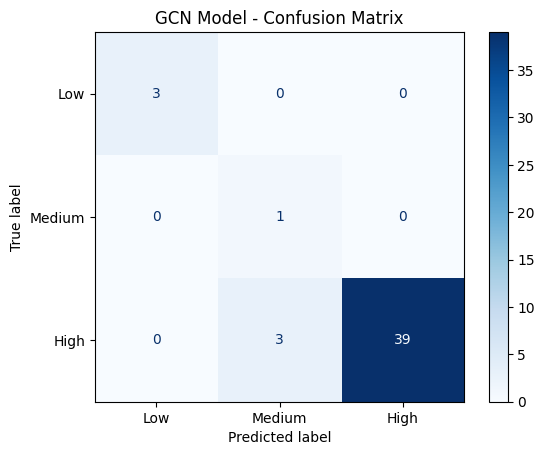


Training GAT model...
GAT Epoch 0, Loss: 3260234334208.0000
GAT Epoch 10, Loss: 830005968896.0000
GAT Epoch 20, Loss: 345763807232.0000
GAT Epoch 30, Loss: 219985723392.0000
GAT Epoch 40, Loss: 281127092224.0000
GAT Epoch 50, Loss: 175966584832.0000
GAT Epoch 60, Loss: 198896582656.0000
GAT Epoch 70, Loss: 79720480768.0000
GAT Epoch 80, Loss: 147850395648.0000
GAT Epoch 90, Loss: 210185142272.0000


<Figure size 600x500 with 0 Axes>

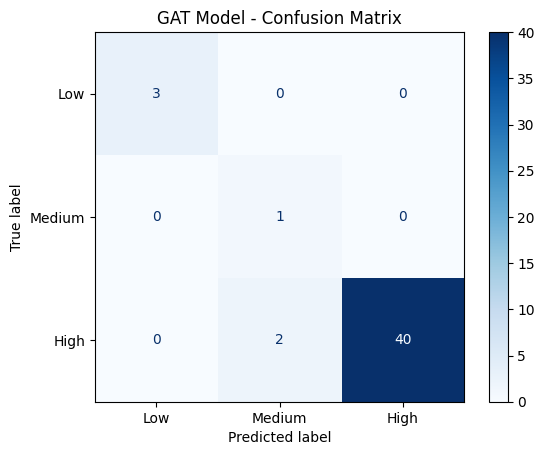


--- GCN Model Evaluation ---
MAE: 379380.22, RMSE: 845651.28, R²: 0.6517
Accuracy: 0.9348, F1 Score: 0.9531

--- GAT Model Evaluation ---
MAE: 69867.37, RMSE: 151262.17, R²: 0.9889
Accuracy: 0.9565, F1 Score: 0.9669
CVXPY Optimization Result: 10.0
Scipy Optimization Result: [9.99999999]


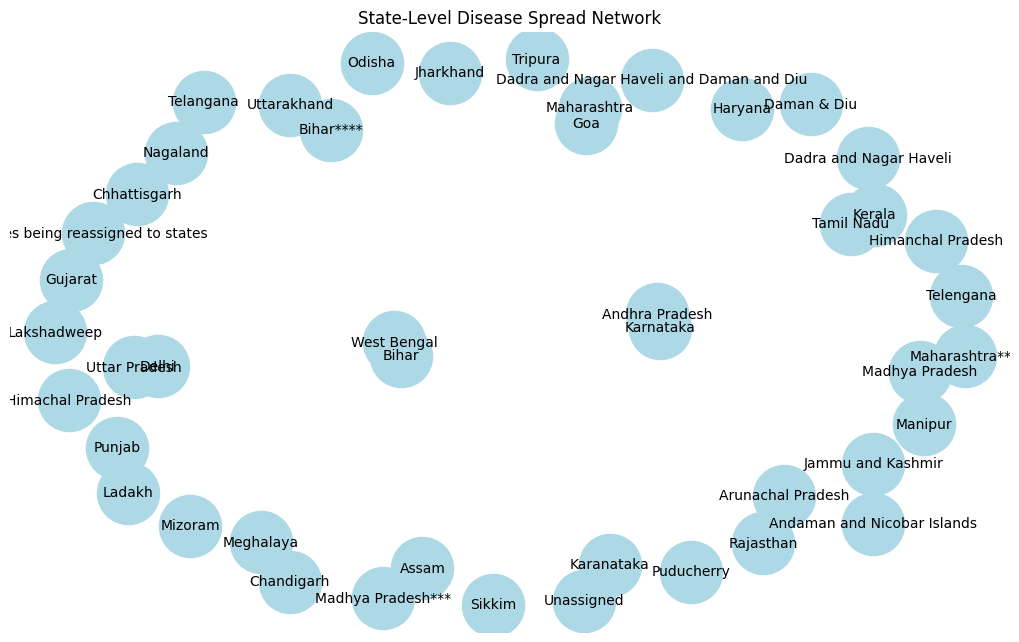

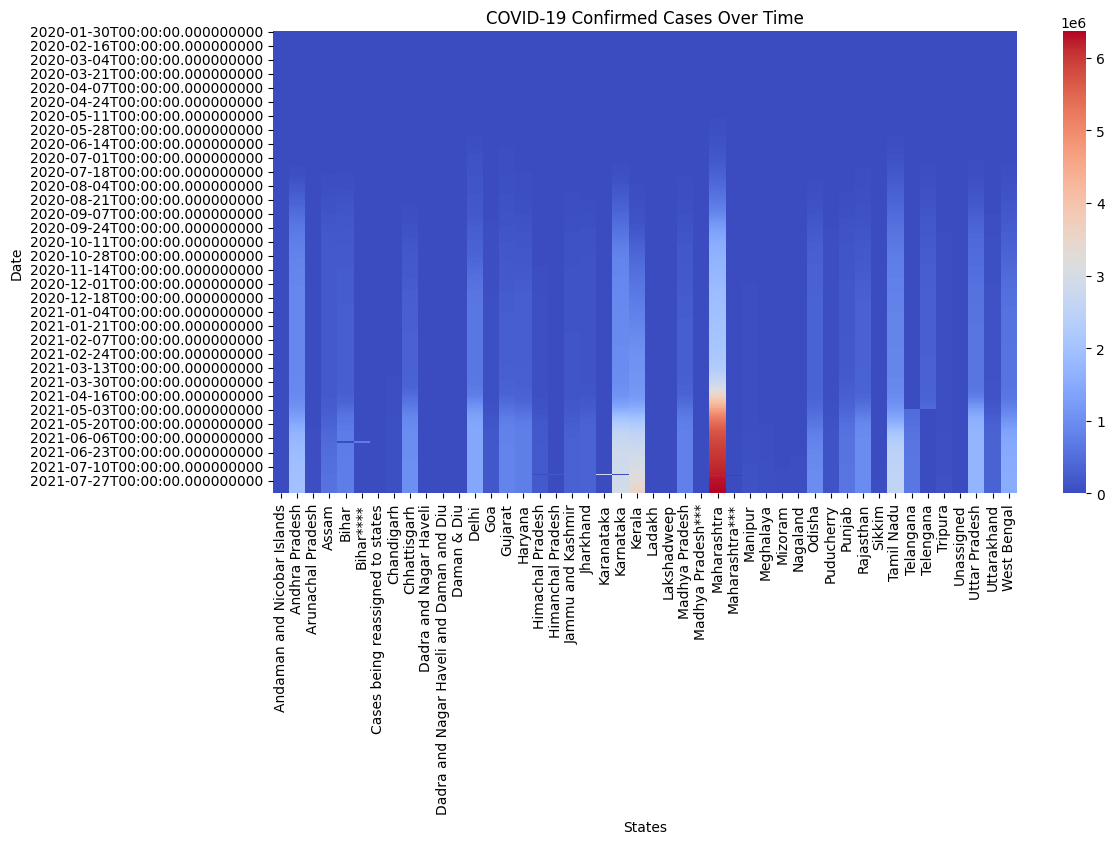

In [ ]:
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv
import cvxpy as cp
from scipy.optimize import minimize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "/content/covid_19_india.csv"
df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])
df['Confirmed'] = pd.to_numeric(df['Confirmed'], errors='coerce')

grouped_df = df.groupby(['Date', 'State/UnionTerritory']).sum().reset_index()


G = nx.Graph()
states = grouped_df['State/UnionTerritory'].unique()
G.add_nodes_from(states)

edges = [("Kerala", "Tamil Nadu"), ("Delhi", "Uttar Pradesh"), ("Maharashtra", "Goa"),
         ("West Bengal", "Bihar"), ("Karnataka", "Andhra Pradesh")]
G.add_edges_from(edges)


features = []
labels = []
state_to_idx = {state: i for i, state in enumerate(states)}

for state in states:
    state_data = grouped_df[grouped_df['State/UnionTerritory'] == state]
    confirmed_cases = state_data['Confirmed'].values[-1] if not state_data.empty else 0
    mobility = state_data['Confirmed'].diff().fillna(0).values[-1] if len(state_data) > 1 else 0  # Simulated mobility data
    features.append([confirmed_cases, mobility])
    labels.append(confirmed_cases)

# Convert to PyTorch Geometric Data format
x = torch.tensor(features, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.float)
edge_index = torch.tensor([[state_to_idx[e[0]], state_to_idx[e[1]]] for e in edges], dtype=torch.long).t().contiguous()
data = Data(x=x, edge_index=edge_index, y=y)

# Define GCN Model
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(2, 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Define GAT Model
class GAT(torch.nn.Module):
    def __init__(self):
        super(GAT, self).__init__()
        self.conv1 = GATConv(2, 16, heads=4, dropout=0.2)
        self.conv2 = GATConv(16 * 4, 1, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Train both models and evaluate
results = {}

for name, model_class in [('GCN', GCN), ('GAT', GAT)]:
    print(f"\nTraining {name} model...")
    model = model_class()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.MSELoss()

    def train():
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out.squeeze(), data.y)
        loss.backward()
        optimizer.step()
        return loss.item()

    for epoch in range(100):
        loss = train()
        if epoch % 10 == 0:
            print(f"{name} Epoch {epoch}, Loss: {loss:.4f}")

    model.eval()
    with torch.no_grad():
        preds = model(data).squeeze().numpy()
        true_vals = data.y.numpy()

    mae = mean_absolute_error(true_vals, preds)
    mse = mean_squared_error(true_vals, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_vals, preds)

    pred_classes = [0 if p <= 1000 else 1 if p <= 10000 else 2 for p in preds]
    true_classes = [0 if t <= 1000 else 1 if t <= 10000 else 2 for t in true_vals]
    cm = confusion_matrix(true_classes, pred_classes, labels=[0, 1, 2])
    acc = accuracy_score(true_classes, pred_classes)
    f1 = f1_score(true_classes, pred_classes, average='weighted')

    results[name] = {
        'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2,
        'confusion_matrix': cm, 'accuracy': acc, 'f1': f1
    }

    # Display Confusion Matrix
    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Model - Confusion Matrix")
    plt.show()

for model_name, metrics in results.items():
    print(f"\n--- {model_name} Model Evaluation ---")
    print(f"MAE: {metrics['mae']:.2f}, RMSE: {metrics['rmse']:.2f}, R²: {metrics['r2']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}, F1 Score: {metrics['f1']:.4f}")

# CVXPY Optimization
x_opt = cp.Variable()
objective = cp.Minimize((x_opt - 10)**2)
constraints = [x_opt >= 5]
prob = cp.Problem(objective, constraints)
result = prob.solve()
print(f"CVXPY Optimization Result: {x_opt.value}")

# Scipy Optimization
def objective_fn(x):
    return (x - 10)**2

opt_result = minimize(objective_fn, x0=[0], bounds=[(-10, 20)])
print(f"Scipy Optimization Result: {opt_result.x}")

